In [1]:
import finitewave as fw
import numpy as np
import matplotlib.pyplot as plt


def run_model(model, t_max):
    n = 100
    m = 10
    tissue = fw.CardiacTissueGrid([n, m], dr=0.25)

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=5, volt_value=1,
                                               x_min=0, x_max=5,
                                               y_min=0, y_max=m))

    action_pot_tracker = fw.ActionPotentialTracker()
    action_pot_tracker.node_inds = [[n//2, m//2]]
    action_pot_tracker.step = 1

    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(action_pot_tracker)

    # create model object and set up parameters:
    simulation = fw.CardiacSimulation(dt=0.01, t_max=t_max)
    simulation.cardiac_model = model
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stim_sequence
    simulation.tracker_sequence = tracker_sequence

    # run the model:
    simulation.run()

    times = action_pot_tracker.tracking_times
    act_pot = action_pot_tracker.output

    return times, act_pot

# Aliev Panfilov Model

Running AlievPanfilov on [100, 10] Grid: 100%|██████████| 6000/6000 [00:00<00:00, 29644.83it/s]


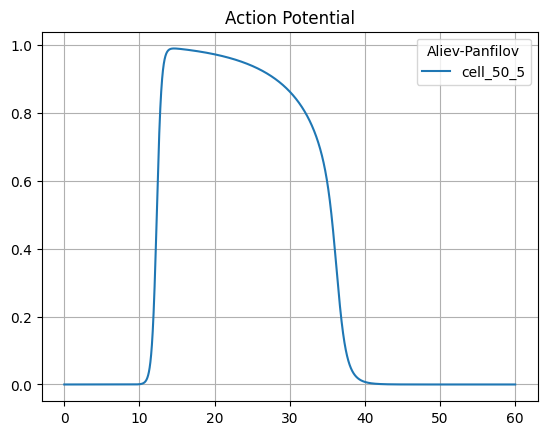

In [2]:
ap_times, ap_values = run_model(fw.AlievPanfilov(), t_max=60)

plt.figure()
plt.plot(ap_times, ap_values, label=f"cell_{50}_{5}")
plt.legend(title='Aliev-Panfilov')
plt.title('Action Potential')
plt.grid()
plt.show()

# Mitchel Schaeffer

Running MitchellSchaeffer on [100, 10] Grid: 100%|██████████| 600/600 [00:00<00:00, 4347.32it/s]


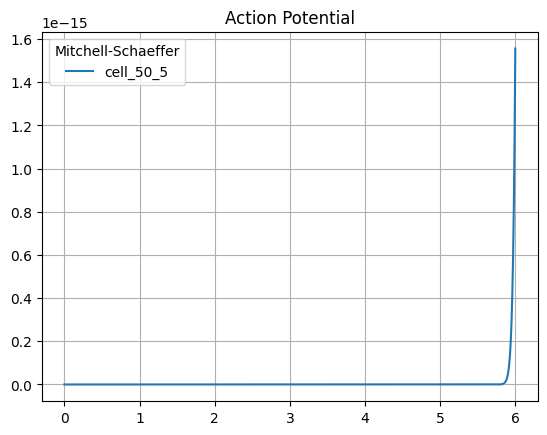

In [3]:
ap_times, ap_values = run_model(fw.MitchellSchaeffer(), t_max=6)

plt.figure()
plt.plot(ap_times, ap_values, label=f"cell_{50}_{5}")
plt.legend(title='Mitchell-Schaeffer')
plt.title('Action Potential')
plt.grid()
plt.show()